<Figure size 800x800 with 0 Axes>

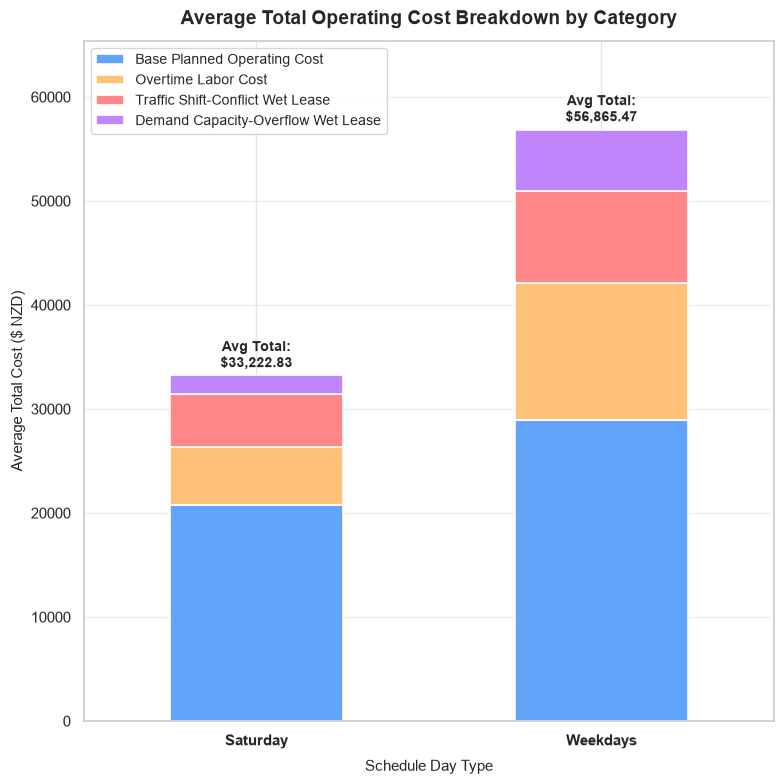

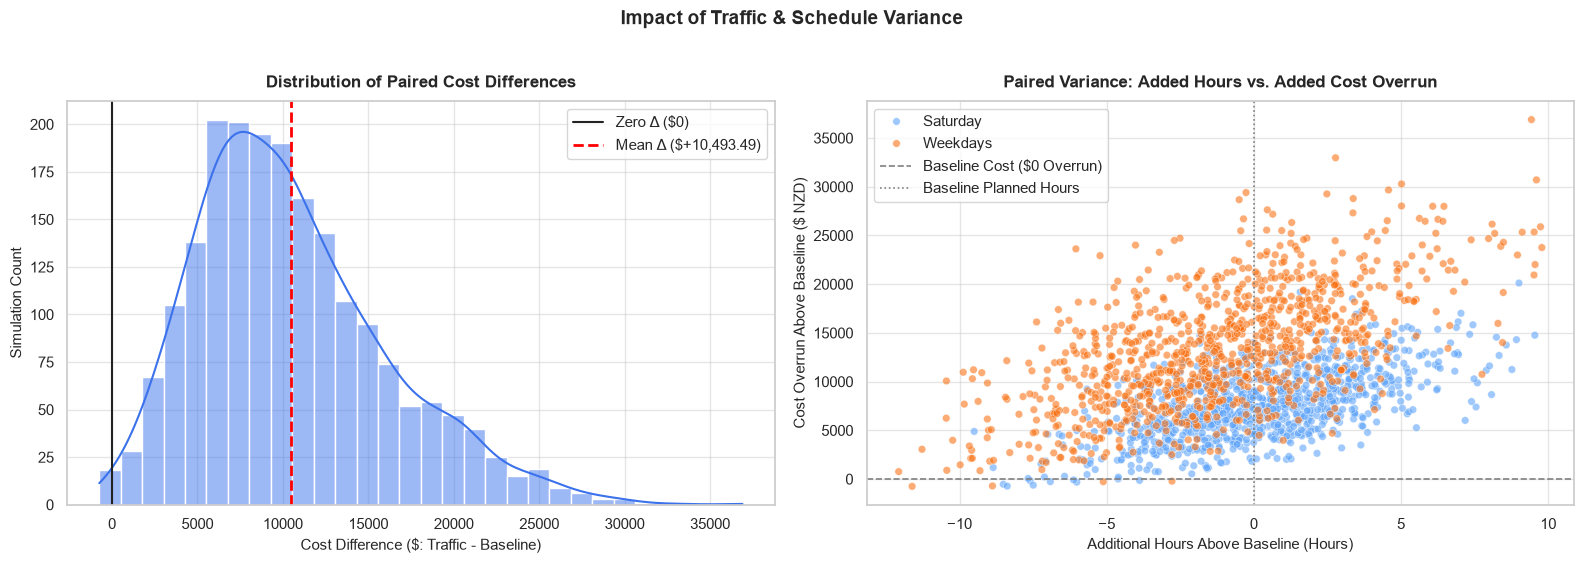

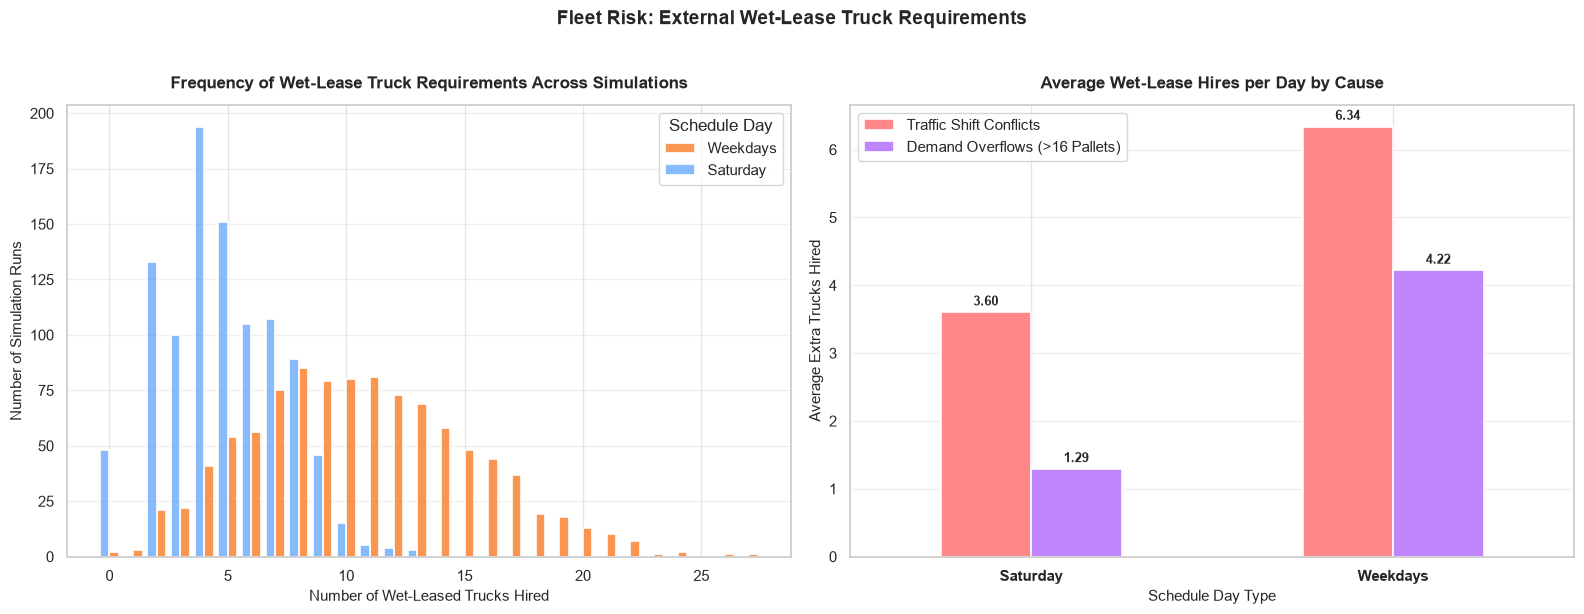

In [66]:
# %%
# ==============================================================================
# REWRITTEN MONTE CARLO SIMULATION & VISUALIZATION PIPELINE
# ==============================================================================

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# ------------------------------------------------------------------------------
# 1. PARAMETERS & CONSTANTS
# ------------------------------------------------------------------------------
N_SIMULATIONS = 1000
RANDOM_SEED = 263

# Financial & Operational Constraints
UNLOAD_MINUTES_PER_PALLET = 18.0
TRUCK_COST_PER_HOUR = 220.0
OVERTIME_THRESHOLD_HOURS = 4.0
OVERTIME_COST_PER_HOUR = 310.0
WET_LEASE_COST_PER_2H_BLOCK = 1400.0
TRUCK_CAPACITY = 16.0
CONFLICT_GRACE_PERIOD_MINUTES = 0

# Stochastic Variance Parameters
SHIFT_TO_SHIFT_SIGMA = 0.10
ROUTE_TO_ROUTE_SIGMA = 0.06
DEMAND_SIGMA_FRACTION = 0.15

SHIFT_TRAFFIC_MEAN = {"8am": 1.03, "2pm": 1.02}

# Global Plot Style
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------------------
# 2. DATA PREPROCESSING & SIMULATION ENGINE
# ------------------------------------------------------------------------------
def preprocess_routes(file_path: str) -> pd.DataFrame:
    """Loads route data and assigns shifts and truck IDs consistently."""
    df = pd.read_csv(file_path)
    if "Pallets" in df.columns and "Demand" not in df.columns:
        df.rename(columns={"Pallets": "Demand"}, inplace=True)

    df["Scheduled_Shift"] = "8am"
    for _, group_idx in df.groupby("Day").groups.items():
        half = len(group_idx) // 2
        df.loc[group_idx.values[half:], "Scheduled_Shift"] = "2pm"

    for _, group_idx in df.groupby("Scheduled_Shift").groups.items():
        for i, idx in enumerate(group_idx):
            df.loc[idx, "Truck"] = f"Truck_{i + 1}"

    return df


def run_simulation(
    group: pd.DataFrame, n_simulations: int, rng: np.random.Generator
) -> pd.DataFrame:
    """Runs stochastic simulation with accurate base vs overtime cost decomposition."""
    group = group.reset_index(drop=True)
    baseline_pallets = group["Demand"].to_numpy(dtype=float)
    baseline_unload_hours = baseline_pallets * UNLOAD_MINUTES_PER_PALLET / 60.0
    baseline_drive_hours = np.maximum(
        0.0, group["Duration_hours"].to_numpy() - baseline_unload_hours
    )
    shifts = group["Scheduled_Shift"].to_numpy()
    trucks = group["Truck"].to_numpy()
    n_routes = len(group)

    # Dynamic baseline planned cost (hours <= 4.0 @ $220/hr)
    planned_hours = np.minimum(
        group["Duration_hours"].to_numpy(), OVERTIME_THRESHOLD_HOURS
    )
    base_planned_cost_val = float((planned_hours * TRUCK_COST_PER_HOUR).sum())

    truck_shift_rows = {}
    for i, (truck, shift) in enumerate(zip(trucks, shifts)):
        truck_shift_rows.setdefault(truck, {})[shift] = i
    double_shift_trucks = {
        truck: rows
        for truck, rows in truck_shift_rows.items()
        if "8am" in rows and "2pm" in rows
    }
    shift_start_hour = {"8am": 8.0, "2pm": 14.0}

    results = []
    for sim in range(1, n_simulations + 1):
        # 1. Demand shocks
        demand_sim = rng.normal(
            baseline_pallets, baseline_pallets * DEMAND_SIGMA_FRACTION
        )
        demand_sim = np.clip(np.round(demand_sim), 0, None)

        capped_demand = np.minimum(demand_sim, TRUCK_CAPACITY)
        overflow_demand = np.maximum(0.0, demand_sim - TRUCK_CAPACITY)
        unload_hours_sim = capped_demand * UNLOAD_MINUTES_PER_PALLET / 60.0

        # 2. Traffic shocks
        traffic_factor = np.empty(n_routes)
        for shift_name, mean_mult in SHIFT_TRAFFIC_MEAN.items():
            mask = shifts == shift_name
            if not mask.any():
                continue
            shift_draw = rng.lognormal(
                mean=math.log(mean_mult) - 0.5 * SHIFT_TO_SHIFT_SIGMA**2,
                sigma=SHIFT_TO_SHIFT_SIGMA,
            )
            route_draws = rng.lognormal(
                mean=-0.5 * ROUTE_TO_ROUTE_SIGMA**2,
                sigma=ROUTE_TO_ROUTE_SIGMA,
                size=mask.sum(),
            )
            traffic_factor[mask] = shift_draw * route_draws

        # 3. Calculate actual route durations
        actual_hours = baseline_drive_hours * traffic_factor + unload_hours_sim

        # 4. Standard and overtime labor cost calculations
        base_costs = np.minimum(actual_hours, OVERTIME_THRESHOLD_HOURS) * TRUCK_COST_PER_HOUR
        overtime_hours = np.maximum(0.0, actual_hours - OVERTIME_THRESHOLD_HOURS)
        overtime_costs = np.array([
            math.ceil(h - 1e-12) * OVERTIME_COST_PER_HOUR if h > 0 else 0.0
            for h in overtime_hours
        ])

        # 5. Wet lease costs from demand capacity overflows
        overflow_cost = 0.0
        n_overflow_events = int((overflow_demand > 0).sum())
        if n_overflow_events > 0:
            overflow_hours = (
                baseline_drive_hours
                + overflow_demand * UNLOAD_MINUTES_PER_PALLET / 60.0
            )
            overflow_hours = overflow_hours[overflow_demand > 0]
            overflow_blocks = np.ceil(overflow_hours / 2.0 - 1e-12)
            overflow_cost = float(
                (overflow_blocks * WET_LEASE_COST_PER_2H_BLOCK).sum()
            )

        # 6. Wet lease costs from traffic schedule conflicts (AM shift overrun)
        wet_lease_cost = 0.0
        n_conflicts = 0
        route_costs = base_costs + overtime_costs

        for truck, rows_by_shift in double_shift_trucks.items():
            am_idx, pm_idx = rows_by_shift["8am"], rows_by_shift["2pm"]
            am_finish_clock = shift_start_hour["8am"] + actual_hours[am_idx]
            grace_hours = CONFLICT_GRACE_PERIOD_MINUTES / 60.0
            if am_finish_clock > shift_start_hour["2pm"] + grace_hours:
                n_conflicts += 1
                pm_wet_lease = (
                    math.ceil(actual_hours[pm_idx] / 2.0 - 1e-12)
                    * WET_LEASE_COST_PER_2H_BLOCK
                )
                route_costs[pm_idx] = pm_wet_lease
                wet_lease_cost += pm_wet_lease

        total_cost = route_costs.sum() + overflow_cost

        results.append({
            "simulation": sim,
            "total_hours": actual_hours.sum(),
            "base_planned_cost": base_planned_cost_val,
            "overtime_cost": overtime_costs.sum(),
            "wet_lease_cost": wet_lease_cost,
            "overflow_cost": overflow_cost,
            "total_cost": total_cost,
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------------------------
# 3. RUN SIMULATION & EXTRACT METRICS
# ------------------------------------------------------------------------------
routes_df = preprocess_routes("project_data/Optimal_Routes.csv")
rng = np.random.default_rng(RANDOM_SEED)

all_sims = []
for day_label, group in routes_df.groupby("Day"):
    sim_df = run_simulation(group, N_SIMULATIONS, rng)
    sim_df.insert(0, "Day", day_label)
    all_sims.append(sim_df)

sim_results_df = pd.concat(all_sims, ignore_index=True)

# Baseline duration mapping for paired difference calculations
baseline_hours = routes_df.groupby("Day")["Duration_hours"].sum().to_dict()
baseline_costs = (
    routes_df.groupby("Day")["Trip_Cost_NZD"].sum().to_dict()
    if "Trip_Cost_NZD" in routes_df.columns
    else sim_results_df.groupby("Day")["base_planned_cost"].mean().to_dict()
)

sim_results_df["Baseline_Cost"] = sim_results_df["Day"].map(baseline_costs)
sim_results_df["Cost_Diff"] = sim_results_df["total_cost"] - sim_results_df["Baseline_Cost"]
sim_results_df["Delta_Hours"] = sim_results_df.apply(
    lambda r: r["total_hours"] - baseline_hours[r["Day"]], axis=1
)

mean_diff = sim_results_df["Cost_Diff"].mean()

# WET-LEASE DERIVATIVE COLUMNS
WET_LEASE_COST_PER_2H_BLOCK = 1400.0
sim_results_df["Traffic_Wet_Leases"] = (
    sim_results_df["wet_lease_cost"] / WET_LEASE_COST_PER_2H_BLOCK
).astype(int)
sim_results_df["Overflow_Wet_Leases"] = (
    sim_results_df["overflow_cost"] / WET_LEASE_COST_PER_2H_BLOCK
).astype(int)
sim_results_df["Total_Wet_Leases"] = (
    sim_results_df["Traffic_Wet_Leases"] + sim_results_df["Overflow_Wet_Leases"]
)

# ------------------------------------------------------------------------------
# 4. VISUALIZATION 1: AVERAGE TOTAL COST BREAKDOWN BY CATEGORY
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 8))

cost_breakdown = sim_results_df.groupby("Day").agg(
    Base_Planned_Cost=("base_planned_cost", "mean"),
    Overtime_Labor_Cost=("overtime_cost", "mean"),
    Traffic_Wet_Lease=("wet_lease_cost", "mean"),
    Demand_Overflow_Wet_Lease=("overflow_cost", "mean"),
).reset_index()

category_colors = ["#60A5FA", "#FFC078", "#FF8787", "#C084FC"]

ax2 = cost_breakdown.set_index("Day").plot(
    kind="bar",
    stacked=True,
    figsize=(8, 8),
    color=category_colors,
    edgecolor="white",
    linewidth=1.2,
)

plt.title(
    "Average Total Operating Cost Breakdown by Category",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Schedule Day Type", fontsize=11, labelpad=8)
plt.ylabel("Average Total Cost ($ NZD)", fontsize=11)
plt.xticks(rotation=0, fontsize=11, fontweight="bold")
plt.grid(axis="y", linestyle="-", alpha=0.3)

max_val = (
    cost_breakdown["Base_Planned_Cost"]
    + cost_breakdown["Overtime_Labor_Cost"]
    + cost_breakdown["Traffic_Wet_Lease"]
    + cost_breakdown["Demand_Overflow_Wet_Lease"]
).max()
ax2.set_ylim(0, max_val * 1.15)

for i, row in cost_breakdown.iterrows():
    total = (
        row["Base_Planned_Cost"]
        + row["Overtime_Labor_Cost"]
        + row["Traffic_Wet_Lease"]
        + row["Demand_Overflow_Wet_Lease"]
    )
    ax2.annotate(
        f"Avg Total:\n${total:,.2f}",
        (i, total),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontweight="bold",
        fontsize=10,
    )

plt.legend(
    labels=[
        "Base Planned Operating Cost",
        "Overtime Labor Cost",
        "Traffic Shift-Conflict Wet Lease",
        "Demand Capacity-Overflow Wet Lease",
    ],
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    fontsize=10,
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. VISUALIZATION 2: IMPACT OF TRAFFIC & SCHEDULE VARIANCE PLOT
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

sns.histplot(
    data=sim_results_df,
    x="Cost_Diff",
    color="#3b72ec",
    kde=True,
    bins=30,
    edgecolor="white",
    alpha=0.5,
    ax=ax1,
)
ax1.axvline(0, color="#222222", linestyle="-", linewidth=1.5, label="Zero Δ ($0)")
ax1.axvline(
    mean_diff,
    color="red",
    linestyle="--",
    linewidth=2.0,
    label=f"Mean Δ (${mean_diff:+,.2f})",
)
ax1.set_title(
    "Distribution of Paired Cost Differences", fontsize=12, fontweight="bold", pad=10
)
ax1.set_xlabel("Cost Difference ($: Traffic - Baseline)", fontsize=11)
ax1.set_ylabel("Simulation Count", fontsize=11)
ax1.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#cccccc")

sns.scatterplot(
    data=sim_results_df,
    x="Delta_Hours",
    y="Cost_Diff",
    hue="Day",
    palette={"Saturday": "#60A5FA", "Weekdays": "#F97316"},
    alpha=0.6,
    s=30,
    ax=ax2,
)

ax2.axhline(
    0, color="gray", linestyle="--", linewidth=1.2, label="Baseline Cost ($0 Overrun)"
)
ax2.axvline(
    0, color="gray", linestyle=":", linewidth=1.2, label="Baseline Planned Hours"
)

ax2.set_title(
    "Paired Variance: Added Hours vs. Added Cost Overrun",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax2.set_xlabel("Additional Hours Above Baseline (Hours)", fontsize=11)
ax2.set_ylabel("Cost Overrun Above Baseline ($ NZD)", fontsize=11)
ax2.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#cccccc")

plt.suptitle(
    "Impact of Traffic & Schedule Variance", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. VISUALIZATION 3: REFINED WET-LEASE FLEET ANALYSIS PLOTS
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=sim_results_df,
    x="Total_Wet_Leases",
    hue="Day",
    palette={"Saturday": "#60A5FA", "Weekdays": "#F97316"},
    discrete=True,
    multiple="dodge",
    shrink=0.8,
    edgecolor="white",
    linewidth=1.2,
    ax=ax1,
)

ax1.set_title(
    "Frequency of Wet-Lease Truck Requirements Across Simulations",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax1.set_xlabel("Number of Wet-Leased Trucks Hired", fontsize=11)
ax1.set_ylabel("Number of Simulation Runs", fontsize=11)
ax1.grid(axis="y", linestyle="-", alpha=0.3)
ax1.legend(
    title="Schedule Day",
    labels=["Weekdays", "Saturday"],
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
)

cause_df = (
    sim_results_df.groupby("Day")[["Traffic_Wet_Leases", "Overflow_Wet_Leases"]]
    .mean()
    .reset_index()
)

ax2 = cause_df.set_index("Day").plot(
    kind="bar",
    color=["#FF8787", "#C084FC"],
    edgecolor="white",
    linewidth=1.2,
    ax=ax2,
)

ax2.set_title(
    "Average Wet-Lease Hires per Day by Cause",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax2.set_xlabel("Schedule Day Type", fontsize=11)
ax2.set_ylabel("Average Extra Trucks Hired", fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontweight="bold")
ax2.grid(axis="y", linestyle="-", alpha=0.3)
ax2.legend(
    ["Traffic Shift Conflicts", "Demand Overflows (>16 Pallets)"],
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
)

for container in ax2.containers:
    for bar in container:
        val = bar.get_height()
        if val > 0:
            ax2.annotate(
                f"{val:.2f}",
                (bar.get_x() + bar.get_width() / 2, val),
                ha="center",
                va="bottom",
                xytext=(0, 3),
                textcoords="offset points",
                fontsize=9,
                fontweight="bold",
            )

plt.suptitle(
    "Fleet Risk: External Wet-Lease Truck Requirements",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()